In [41]:
import pandas as pd
import numpy as np
import json
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [42]:
transactions = pd.read_excel('transactions_data.xlsx')
clients = pd.read_json('clients_data.json')

Этап 1: Очистка и подготовка данных (начинаю с transactions)

In [43]:
transactions.info()
transactions.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    9526 non-null   object 
 1   client_id         9798 non-null   object 
 2   transaction_date  10000 non-null  object 
 3   service           10000 non-null  object 
 4   amount            9540 non-null   float64
 5   payment_method    10000 non-null  object 
 6   city              10000 non-null  object 
 7   consultant        10000 non-null  object 
dtypes: float64(1), object(7)
memory usage: 625.1+ KB


,amount
count,9540.000000
mean,49246.781517
std,37961.999532
min,14.044907
25%,19074.838850
50%,41651.706800
75%,71378.894526
max,277442.155248


Нет отрицательных сумм, есть выбросы (max в несколько раз больше среднего), много мелких сумм и меньше крупных (медиана меньше среднего)

In [44]:
transactions.head()

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
0,ff36597c-df41-44a0-9f46-6aa1fe615270,1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7,2025-01-04 00:02:20,Структурирование капитала,55838.059789,Банковский перевод,North Patrickport,Cheryl Waller
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer
3,524031ea-56e2-410a-aee2-e8fc6ae3fbc5,NaN,2025-03-02 03:14:10,Финансовое планирование,2313.980219,Неизвестно,Erichaven,Patricia Haas
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,Неизвестно,Bondstad,Melissa Pena


In [45]:
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'], errors='coerce')
print(f"Пропущенных дат: {transactions['transaction_date'].isnull().sum()}")
transactions[transactions['transaction_date'].isnull()]

Пропущенных дат: 1005


,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
17,125e15aa-1510-436d-b32f-79cc79bd2203,92c2cf71-fbc1-41aa-a88b-f2b702a7e946,NaT,Финансовое планирование,36818.406045,Наличные,Jeanettetown,Sarah Alvarez
18,bf0c08ab-c118-4155-91f4-95f09fe6a1fa,fedfe1eb-e79a-4527-9dd9-991af7e2b34d,NaT,Налоговое планирование,36896.308910,Кредитная карта,North Patrickport,Michelle Morse
25,190ce3c6-8657-437b-b3ba-1cc21dbbe421,53a3dcf3-3707-4fff-b1e1-ee2c4f357e1d,NaT,Управление активами,99420.587888,Наличные,Davidsonborough,Judith Hansen
29,e352563f-985f-46cb-9b1e-37ff7995b338,53113fae-453b-464b-8e39-a0337fc727e1,NaT,Инвестиционное консультирование,10711.465497,Банковский перевод,Cruzport,Ronald Benson
47,f88d0325-637c-4b0b-ad44-954aee483243,926eb57c-e1b9-41b2-a9e8-a3723563c505,NaT,Неизвестная услуга,2348.978021,Кредитная карта,Lake Tina,Kathryn Young
...,...,...,...,...,...,...,...,...
9963,8b8a2648-3982-4e13-8c5a-8d10e4129576,ed9c332f-d02a-411b-9414-9dec002b8821,NaT,Управление активами,15904.945889,Банковский перевод,New Ryan,Mario Jones
9969,c186062d-b9e6-466c-abad-97a708fe90c3,fdee4854-6c12-47a0-a561-710264ce9d24,NaT,Инвестиционное консультирование,79709.903415,Банковский перевод,Hamiltontown,Gregory Williams
9975,920abb78-41ac-442f-bf02-50398562022a,59859b6f-458d-4a72-88ee-48dba4e61574,NaT,Инвестиционное консультирование,13579.842832,Кредитная карта,Patelbury,Judith Hansen
9977,d234eaa5-47c4-4221-9fcf-dac69c9a591a,041d30db-6572-46de-9a57-18b1c9f24034,NaT,Управление активами,32927.948723,Банковский перевод,Michellehaven,Julie Jones


Я обнаружила invalid date при анализе дат, поэтому заменила их на NaT (Not a Time). Удалять не стала, потому что данных очень много, более 10%.

In [46]:
# проверка на дубликаты в transaction_id
duplicate_ids = transactions['transaction_id'].duplicated().sum()
print(f"Дубликатов: {duplicate_ids}")

if duplicate_ids > 0:
    dup_values = transactions[transactions['transaction_id'].duplicated(keep=False)].sort_values('transaction_id')
    print(dup_values.head(5))

Дубликатов: 473
    transaction_id                             client_id    transaction_date  \
11             NaN  740a1f26-a360-4ea2-974e-dbe5c3a3dd4e 2025-03-15 22:41:37   
51             NaN  1b980cce-cdaf-4100-98d6-85cab0bab87c                 NaT   
177            NaN  838e9c50-3158-4357-a9b3-7ce5403108ea                 NaT   
205            NaN  fe500414-9b79-4b96-951e-307963b5dbb3                 NaT   
295            NaN  74a945ec-3089-43f9-b324-6a63260c0aa0 2025-02-05 08:34:52   

                             service        amount      payment_method  \
11               Управление активами  55780.022870  Банковский перевод   
51               Управление активами  89024.961022     Кредитная карта   
177  Инвестиционное консультирование  23286.852038     Кредитная карта   
205        Структурирование капитала  96836.510921     Кредитная карта   
295          Финансовое планирование  95923.806806     Кредитная карта   

                  city        consultant  
11         Ibar

In [47]:
# реальные дубликаты или проблема в NaN?

unique_ids = transactions['transaction_id'].nunique()
nan_count = transactions['transaction_id'].isnull().sum()
non_null = transactions[transactions['transaction_id'].notna()].copy()
real_duplicates = non_null[non_null['transaction_id'].duplicated(keep=False)]

print(f"Уникальных ID: {unique_ids}")
print(f"Всего строк: {len(transactions)}")
print(f"NaN в ID: {nan_count}")
print(f"Реальных дубликатов: {len(real_duplicates)}")

Уникальных ID: 9526
Всего строк: 10000
NaN в ID: 474
Реальных дубликатов: 0


Дубликатов НЕТ. Это просто транзакции без айдишника. Изменять не буду, анализу это не помешает

Далее проверка client_id

In [48]:
# смотрим где нет client_id

no_client = transactions[transactions['client_id'].isnull()].copy()

print(f"Строк без client_id: {len(no_client)}")
print(f"Процент: {len(no_client)/len(transactions)*100:.2f}%")

print("Первые 10:")
print(no_client.head(10))

Строк без client_id: 202
Процент: 2.02%
Первые 10:
                           transaction_id client_id    transaction_date  \
3    524031ea-56e2-410a-aee2-e8fc6ae3fbc5       NaN 2025-03-02 03:14:10   
21   0aed2448-4e41-4dfb-8de5-7a9e6f6d8d33       NaN 2025-01-27 18:27:54   
60   0b83328f-0b7c-41ef-9427-aca57fc103e0       NaN 2025-01-03 16:52:49   
151  336709d3-87f0-422d-9185-29a553c3ced1       NaN 2025-01-11 20:32:04   
152  ec81ae99-2de7-465a-8885-6e9ebaaa24de       NaN                 NaT   
197  6657d528-54a1-4028-a60a-a14f0eab7c16       NaN 2025-02-05 19:13:11   
254  b3a24f73-8e46-4965-b2de-0f1d802dd494       NaN 2025-01-16 01:01:59   
260  df993184-a5da-49e5-b74a-923edd084727       NaN 2025-01-26 05:58:39   
290  4cd9483f-8b2a-459f-a87e-5793da2db232       NaN 2025-01-28 21:35:19   
312  46f72f02-85f6-4839-9037-442af792eb8a       NaN 2025-02-23 08:33:04   

                             service         amount      payment_method  \
3            Финансовое планирование    2313.980

Оставляю данные, так как анализу это не помешает, а на merge с клиентами они сами отвалятся

Смотрим service

In [49]:
# какие есть услуги?

print(transactions['service'].value_counts())

service
Инвестиционное консультирование    2429
Управление активами                2014
Финансовое планирование            1532
Налоговое планирование             1528
Структурирование капитала          1507
Неизвестная услуга                  990
Name: count, dtype: int64


In [50]:
unknown_service = transactions[transactions['service'] == 'Неизвестная услуга']
unknown_service.head(10)

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
6,3f753dcc-d710-4640-bf88-085a52bd0a77,8c65a1e3-05a0-420d-800e-6ea786892ea1,2025-01-29 18:34:35,Неизвестная услуга,18383.907886,Кредитная карта,Johnsonfort,Wendy Cooper
22,8436d6c3-b1b6-499e-bc08-84c10d22b615,d2c35d90-f102-4b9a-bff0-59d2008a6d6e,2025-01-28 04:32:05,Неизвестная услуга,49943.870517,Кредитная карта,Hamiltontown,Wendy Cooper
30,b63f5c93-8fd7-4a79-ad92-e7eda3339975,bbd136c3-7f29-42e0-8abc-d8c4bb81fa69,2025-02-17 08:51:56,Неизвестная услуга,117442.413607,Кредитная карта,Lake Tina,David Thompson
41,1ae9a1fd-c78a-4f35-b881-ba71d2385c68,c49af4d8-f101-4e6b-8c28-560179d19f66,2025-02-11 02:45:18,Неизвестная услуга,141881.371368,Кредитная карта,North Hannahmouth,Chad Raymond
47,f88d0325-637c-4b0b-ad44-954aee483243,926eb57c-e1b9-41b2-a9e8-a3723563c505,NaT,Неизвестная услуга,2348.978021,Кредитная карта,Lake Tina,Kathryn Young
61,b14abe1c-48b5-4c97-b0d4-df533ac65b98,24df891c-d0ed-473d-9a4f-aa6a28aa45cb,2025-01-26 17:49:54,Неизвестная услуга,59536.473078,Банковский перевод,Неизвестный город,Travis Curtis
67,78b36ad1-4964-4a14-9610-7086af19d3c1,261f4f46-21ec-49f0-813a-61ef8c6dcb55,2025-02-24 12:57:45,Неизвестная услуга,6437.256960,Кредитная карта,Erichaven,Lisa Sanchez MD
81,94cef9b2-385c-4ebf-81e5-0024793cfa30,30b6f45b-150f-43bc-be12-833d9a2b7ed7,2025-01-23 17:55:04,Неизвестная услуга,36227.604623,Криптовалюта,New Tommyborough,Неизвестный консультант
133,78a16963-1e4d-454b-a776-2d8195fea95f,fb9f2916-994d-4140-8b94-96a1b607aff7,2025-01-31 08:40:38,Неизвестная услуга,115621.477393,Кредитная карта,Krystalland,Sarah Alvarez
135,3b74170b-7744-47c0-9520-3eb52b322545,8fee1e45-48de-46e0-93ab-d7c00fd6313c,2025-02-17 22:15:25,Неизвестная услуга,87978.758060,Кредитная карта,Erichaven,Nicholas Barry


In [51]:
# есть взаимосвязь с айдишником?
print(f"С client_id: {unknown_service['client_id'].notna().sum()}")
print(f"Без client_id: {unknown_service['client_id'].isnull().sum()}")

С client_id: 976
Без client_id: 14


Неизвестная услуга выглядит как реальная категория (нет корреляции с айдишником, консультантом, суммой или способом оплаты). Может это аналог категории "другое". Оставляем

Смотрим amount

In [52]:
top_amounts = transactions.nlargest(20, 'amount')[['amount', 'service', 'payment_method', 'city', 'consultant']]
print(top_amounts)


             amount                          service      payment_method  \
8207  277442.155248           Налоговое планирование            Наличные   
7478  254563.356257              Управление активами          Неизвестно   
8070  250510.888842  Инвестиционное консультирование            Наличные   
5686  238751.233641  Инвестиционное консультирование     Кредитная карта   
4018  236317.826199           Налоговое планирование     Кредитная карта   
2566  232557.875441  Инвестиционное консультирование            Наличные   
6399  231329.135473          Финансовое планирование     Кредитная карта   
4239  227938.699389           Налоговое планирование            Наличные   
6162  219535.239406  Инвестиционное консультирование  Банковский перевод   
7979  217642.699673               Неизвестная услуга          Неизвестно   
3748  217641.541340              Управление активами     Кредитная карта   
5268  216607.737464  Инвестиционное консультирование  Банковский перевод   
2967  215627

Для анализа это не ошибки, а реальные покупки. Оставляем. Но линейная регрессия супер чувствительна к выбросам, поэтому, скорее всего, придется выкинуть крупные amount либо сделать логарифмирование цен. Если брать первый вариант, то для крупных транзакций можно просто построить отдельную модель.

Перехожу к payment_method

In [53]:
print(transactions['payment_method'].value_counts())

payment_method
Кредитная карта       3999
Банковский перевод    3464
Неизвестно            1008
Наличные               985
Криптовалюта           544
Name: count, dtype: int64


In [54]:
unknown_payment = transactions[transactions['payment_method'] == 'Неизвестно'].copy()
unknown_payment.head(10)

,transaction_id,client_id,transaction_date,service,amount,payment_method,city,consultant
1,0d5263ec-413d-44d9-a9d3-a996e3a56b05,c940f45c-d29b-439a-8fa3-f75018cef528,2025-03-10 17:16:50,Структурирование капитала,37514.809209,Неизвестно,New Zacharyport,Frank Pollard
2,5e9a8978-df1c-483f-a53b-16149c93f11e,cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c,2025-02-13 19:43:49,Структурирование капитала,21022.146872,Неизвестно,Port Michellemouth,Alexandra Meyer
3,524031ea-56e2-410a-aee2-e8fc6ae3fbc5,NaN,2025-03-02 03:14:10,Финансовое планирование,2313.980219,Неизвестно,Erichaven,Patricia Haas
4,421aaf04-c97d-42ac-b35f-09a56bbaf910,3f43d7bc-37f0-4535-8391-51702d6ff81e,2025-03-18 21:00:36,Структурирование капитала,5636.586955,Неизвестно,Bondstad,Melissa Pena
53,e812de5c-6e78-4f53-8390-be7be2cd2b5e,46834f1c-6bfb-4c85-9ce5-9a32e02edd0e,2025-02-05 15:15:34,Структурирование капитала,NaN,Неизвестно,Matthewsville,Joshua Fuentes
96,10a5703d-9020-46e0-89b2-40d979aa045c,eb356a59-d7be-48c3-ad9c-e0b804545c82,2025-01-24 06:53:45,Налоговое планирование,31403.717717,Неизвестно,North Hannahmouth,Mario Jones
108,c94b4a73-db99-4656-9709-4f94db32310b,a0fcad49-94a4-4d38-b18e-9f3419cd7d2d,2025-01-25 21:07:04,Финансовое планирование,NaN,Неизвестно,New Chelseaberg,Jordan Phillips
123,32009aa3-eabb-475a-95a5-8c2e3c85abd6,aa3ee6b5-7363-4b74-a389-c5039e699a3a,2025-01-04 11:36:28,Инвестиционное консультирование,42635.337304,Неизвестно,New Tommyborough,Teresa Baker
129,8d8dba6a-22d8-4626-a11f-a5c5b03932ce,03fc0326-e67e-4966-b4d0-62e245633480,2025-03-07 16:00:55,Налоговое планирование,23811.883272,Неизвестно,Trevinoberg,Travis Curtis
147,046f9a6f-2d20-41bf-b44b-5666eacc8433,72af4d26-5633-4421-a97a-3ce5061e8cd6,NaT,Налоговое планирование,30368.880983,Неизвестно,Lake Arielmouth,Chad Raymond


Та же история, что и с service (Неизвестная услуга). Тоже похоже на отдельную категорию, а не ошибку. Оставляем

Проверим города и консультантов

In [55]:
print(transactions['city'].value_counts())

city
Неизвестный город     383
Karenville            224
North Emily           217
Port James            216
Mirandaside           214
Kaneburgh             212
New Chelseaberg       212
Cruzport              210
North Hannahmouth     208
Erichaven             207
Lake Arielmouth       206
New Dianechester      205
Mayoberg              203
Davidsonborough       203
East Matthewmouth     203
Krystalland           200
New Tommyborough      199
Johnsonfort           199
Trevinoberg           199
Port Jordan           198
North Patrickport     197
South Andrew          197
North Melissaland     196
Patelbury             194
Ibarramouth           192
Port Michellemouth    192
East Rachelmouth      189
Matthewsville         189
West Jaymouth         188
Jeanettetown          188
North Lauriebury      188
Lake Tina             188
Davidmouth            187
New Ryan              187
Aprilstad             186
East Melissaville     185
Michellehaven         183
Lake Sallychester     183
Ronaldv

In [56]:
print(transactions['consultant'].value_counts())

consultant
Неизвестный консультант    368
Deborah Stone              223
Ronald Shepherd            221
Laura Herrera              220
Michelle Morse             217
Kirsten Martin             217
Phillip White              216
Erik Garcia                216
David Palmer               212
Stephen Jones              211
Mario Jones                210
Catherine Lawson           208
Cynthia Coleman            207
Alexandra Meyer            204
Melissa Pena               202
Ronald Benson              200
Kathryn Young              199
Jordan Phillips            198
Travis Curtis              198
Katherine Smith            194
Nicholas Barry             194
Wendy Cooper               193
Teresa Baker               193
Lisa Sanchez MD            192
Timothy Brown              192
Tiffany James              192
Cheryl Waller              191
Chad Raymond               191
Judith Hansen              189
Jessica Bates              189
William Bell               188
Dylan Martin               1

А есть ли взаимосвязь между неизвестным городом и неизвестным консультантом?

In [57]:
# Самые частые пары (консультант, город)
city_consultant_pairs = transactions.groupby(['consultant', 'city']).size().reset_index(name='count')
top_pairs = city_consultant_pairs.sort_values('count', ascending=False).head(20)
print(top_pairs)

                   consultant               city  count
1135          Jordan Phillips  Неизвестный город     15
1485            Laura Herrera  Неизвестный город     14
507              Dylan Martin  East Melissaville     13
347           Cynthia Coleman  Неизвестный город     13
1585              Mario Jones  Неизвестный город     13
499             Deborah Stone  Неизвестный город     12
2524  Неизвестный консультант  North Patrickport     12
1335          Katherine Smith  Неизвестный город     11
2516  Неизвестный консультант   New Dianechester     11
2538  Неизвестный консультант  Неизвестный город     11
625             Emily Stewart   New Dianechester     11
2520  Неизвестный консультант        North Emily     11
1429           Kirsten Martin       South Andrew     10
598            Edwin Cantrell  Неизвестный город     10
1904        Rachel Williamson          Kaneburgh     10
1663             Melissa Pena   New Dianechester     10
2526  Неизвестный консультант       Port Darlene

In [58]:
unknown_consultant = transactions[transactions['consultant'] == 'Неизвестный консультант']
print(unknown_consultant['city'].value_counts().head(10))
print(f"Всего городов у неизвестного консультанта: {unknown_consultant['city'].nunique()}")

city
North Patrickport    12
North Emily          11
Неизвестный город    11
New Dianechester     11
Port Darlene         10
Lake Sallychester    10
Johnsonfort           9
Krystalland           9
Jeanettetown          9
Erichaven             9
Name: count, dtype: int64
Всего городов у неизвестного консультанта: 51


In [59]:
unknown_city = transactions[transactions['city'] == 'Неизвестный город']
print(unknown_city['consultant'].value_counts().head(10))
print(f"Всего консультантов в неизвестном городе: {unknown_city['consultant'].nunique()}")

consultant
Jordan Phillips            15
Laura Herrera              14
Mario Jones                13
Cynthia Coleman            13
Deborah Stone              12
Неизвестный консультант    11
Katherine Smith            11
David Palmer               10
Edwin Cantrell             10
David Thompson             10
Name: count, dtype: int64
Всего консультантов в неизвестном городе: 51


Вывод - неизвестный консультант и неизвестный город НЕ связаны. Но есть консультанты (Jordan Phillips, Laura Herrera, Mario Jones), которые работают чаще всего с неизвестными городами. Возможно, систематически забывают их указывать

Переходим к clients_data

In [60]:
print(clients.shape)
print(clients.info())
print(clients.describe())
print(clients.head(15))

(9799, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9799 entries, 0 to 9798
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         9798 non-null   object 
 1   age        8816 non-null   float64
 2   gender     6480 non-null   object 
 3   net_worth  9324 non-null   float64
dtypes: float64(2), object(2)
memory usage: 306.3+ KB
None
               age     net_worth
count  8816.000000  9.324000e+03
mean     40.052291  2.501561e+06
std      11.823810  1.430787e+06
min      20.000000  1.021397e+04
25%      30.000000  1.263024e+06
50%      40.000000  2.488230e+06
75%      50.000000  3.727101e+06
max      60.000000  4.999428e+06
                                      id   age   gender   net_worth
0   1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7  41.0  Мужчина  2514729.46
1   c940f45c-d29b-439a-8fa3-f75018cef528  28.0  Мужчина   566568.29
2   cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c  55.0  Женщина  1896001.28
3               

По айдишнику один пропуск, около 10% пропусков по age, более 30% по gender, в net_worth нет цифровых аномалий, маленькое кол-во пропусков

In [61]:
# удаляю человека без id

clients = clients.dropna(subset=['id']).copy()

In [62]:
# заполняю пропуски в age медианой

median_age = clients['age'].median()
clients['age'] = clients['age'].fillna(median_age)

In [63]:
# удаляю клиентов с пустыми net_worth, ибо для сегментации клиентов по активам 
# принципиально знать стоимость

clients = clients.dropna(subset=['net_worth']).copy()

In [64]:
# отдельная категория для пустого gender

clients['gender'] = clients['gender'].fillna('Неизвестно')
print(clients['gender'].value_counts())

gender
Неизвестно    3164
Женщина       3128
Мужчина       3031
Name: count, dtype: int64


Этап 2: анализ

In [65]:
# топ 5 услуг по кол-ву заказов

top_services = transactions['service'].value_counts().head(5)
print(top_services)

service
Инвестиционное консультирование    2429
Управление активами                2014
Финансовое планирование            1532
Налоговое планирование             1528
Структурирование капитала          1507
Name: count, dtype: int64


In [106]:
# средняя сумма транзакций по каждому городу

avg_by_city = transactions.groupby('city')['amount'].mean().sort_values(ascending=False)
print(avg_by_city.head(5))
print(avg_by_city.tail(5))

city
Port Michellemouth    55923.641747
Michellehaven         55612.060424
East Rachelmouth      54315.271417
New Tommyborough      53655.493999
Trevinoberg           53032.459413
Name: amount, dtype: float64
city
Mirandaside       45018.996216
Matthewsville     44712.180316
Elizabethmouth    44373.453087
Jeanettetown      43862.067530
East Jamie        42739.080823
Name: amount, dtype: float64


In [67]:
# услуга с наибольшей выручкой

revenue_by_service = transactions.groupby('service')['amount'].sum().sort_values(ascending=False)
print("Выручка по услугам:")
print(revenue_by_service)

top_service_revenue = revenue_by_service.index[0]
top_revenue = revenue_by_service.iloc[0]
print(f"Услуга с наибольшей выручкой: {top_service_revenue} ({top_revenue:,.0f} руб.)")

Выручка по услугам:
service
Инвестиционное консультирование    1.150141e+08
Управление активами                9.403813e+07
Финансовое планирование            7.225539e+07
Налоговое планирование             7.135203e+07
Структурирование капитала          6.893256e+07
Неизвестная услуга                 4.822210e+07
Name: amount, dtype: float64
Услуга с наибольшей выручкой: Инвестиционное консультирование (115,014,089 руб.)


In [68]:
# процент транзакций по способам оплаты

payment_pct = transactions['payment_method'].value_counts(normalize=True) * 100
print(payment_pct.round(1))

payment_method
Кредитная карта       40.0
Банковский перевод    34.6
Неизвестно            10.1
Наличные               9.8
Криптовалюта           5.4
Name: proportion, dtype: float64


In [69]:
# выручка за последний месяц
# а что такое последний месяц?

print(f"Мин дата: {transactions['transaction_date'].min()}")
print(f"Макс дата: {transactions['transaction_date'].max()}")

last_month = transactions['transaction_date'].max().month
last_year = transactions['transaction_date'].max().year

last_month_transactions = transactions[
    (transactions['transaction_date'].dt.month == last_month) & 
    (transactions['transaction_date'].dt.year == last_year)
]

last_month_revenue = last_month_transactions['amount'].sum()
print(f"Выручка за последний месяц ({last_month}.{last_year}): {last_month_revenue:,.0f} руб.")


Мин дата: 2025-01-01 00:20:40
Макс дата: 2025-03-20 12:30:55
Выручка за последний месяц (3.2025): 105,257,878 руб.


Последний месяц в данных это март (неполный)

In [70]:
# последний полный месяц (ферваль)

february_transactions = transactions[
    (transactions['transaction_date'].dt.year == 2025) & 
    (transactions['transaction_date'].dt.month == 2)
]

february_revenue = february_transactions['amount'].sum()

print(f"За февраль: {february_revenue:,.0f} руб.")

За февраль: 148,002,146 руб.


Этап 3: объединение данных

In [72]:
merged = pd.merge(
    transactions,
    clients,
    left_on='client_id',
    right_on='id',
    how='inner'
)

print(merged.head())

                         transaction_id                             client_id  \
0  ff36597c-df41-44a0-9f46-6aa1fe615270  1ec5ab91-fdd0-4925-a221-f0c4e04fe0e7   
1  0d5263ec-413d-44d9-a9d3-a996e3a56b05  c940f45c-d29b-439a-8fa3-f75018cef528   
2  5e9a8978-df1c-483f-a53b-16149c93f11e  cfa21d7e-8499-43d0-9dfb-f4a1b94ce44c   
3  421aaf04-c97d-42ac-b35f-09a56bbaf910  3f43d7bc-37f0-4535-8391-51702d6ff81e   
4  822d5795-4f08-4a7a-9692-7f5863945bdf  900f7d6b-ee7f-49e6-ae9f-e5ea9e04ab4c   

     transaction_date                          service        amount  \
0 2025-01-04 00:02:20        Структурирование капитала  55838.059789   
1 2025-03-10 17:16:50        Структурирование капитала  37514.809209   
2 2025-02-13 19:43:49        Структурирование капитала  21022.146872   
3 2025-03-18 21:00:36        Структурирование капитала   5636.586955   
4 2025-02-21 21:50:30  Инвестиционное консультирование  85575.773285   

       payment_method                city       consultant  \
0  Банковский пере

Новая колонка с уровнями активов

In [74]:
def wealth_level(net_worth):
    if net_worth < 100000:
        return 'Низкий'
    elif net_worth <= 1000000:
        return 'Средний'
    else:
        return 'Высокий'

merged['wealth_level'] = merged['net_worth'].apply(wealth_level)

print(merged['wealth_level'].value_counts())

wealth_level
Высокий    7510
Средний    1639
Низкий      174
Name: count, dtype: int64


In [77]:
revenue_by_wealth = merged.groupby('wealth_level')['amount'].sum().sort_values(ascending=False)
print("Выручка по уровням активов:")
print(revenue_by_wealth)
print()
total_revenue = merged['amount'].sum()
print("% от общей выручки:")
print((revenue_by_wealth / total_revenue * 100).round(1))

Выручка по уровням активов:
wealth_level
Высокий    3.545294e+08
Средний    7.482517e+07
Низкий     7.955070e+06
Name: amount, dtype: float64

% от общей выручки:
wealth_level
Высокий    81.1
Средний    17.1
Низкий      1.8
Name: amount, dtype: float64


In [79]:
count_by_wealth = merged.groupby('wealth_level').size()
print("Кол-во транзакций:")
print(count_by_wealth)
print()
avg_by_wealth = merged.groupby('wealth_level')['amount'].mean().round(0)
print("Средний чек:")
print(avg_by_wealth)

Кол-во транзакций:
wealth_level
Высокий    7510
Низкий      174
Средний    1639
dtype: int64

Средний чек:
wealth_level
Высокий    49370.0
Низкий     47922.0
Средний    48337.0
Name: amount, dtype: float64


Основу бизнеса составляют клиенты с высоким капиталом: 81.1% выручки. Клиенты со средним капиталом дают 17.1% выручки, а низкокапитальные практически не представлены. Но так как средние чеки примерно одинаковые во всех группах, разница обусловлена кол-вом клиентов либо частотой транзакций

Этап 4: визуализация

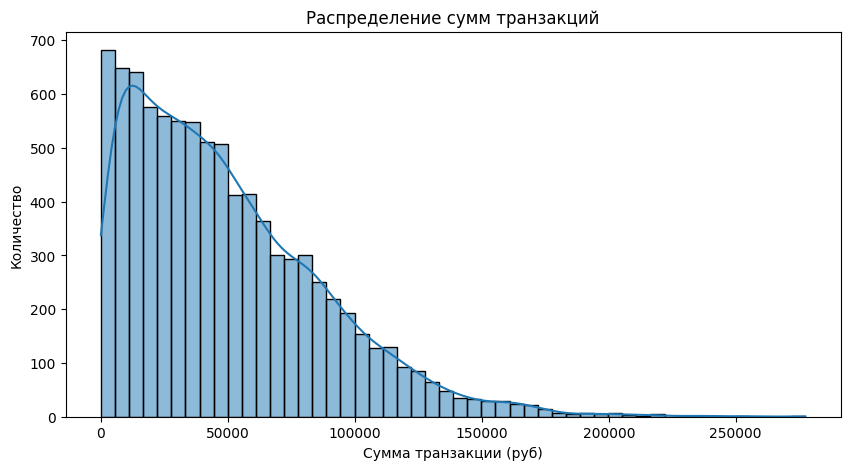

In [92]:
plt.figure(figsize=(10, 5))
sns.histplot(merged['amount'], bins=50, kde=True)
plt.title('Распределение сумм транзакций')
plt.xlabel('Сумма транзакции (руб)')
plt.ylabel('Количество')
plt.show()

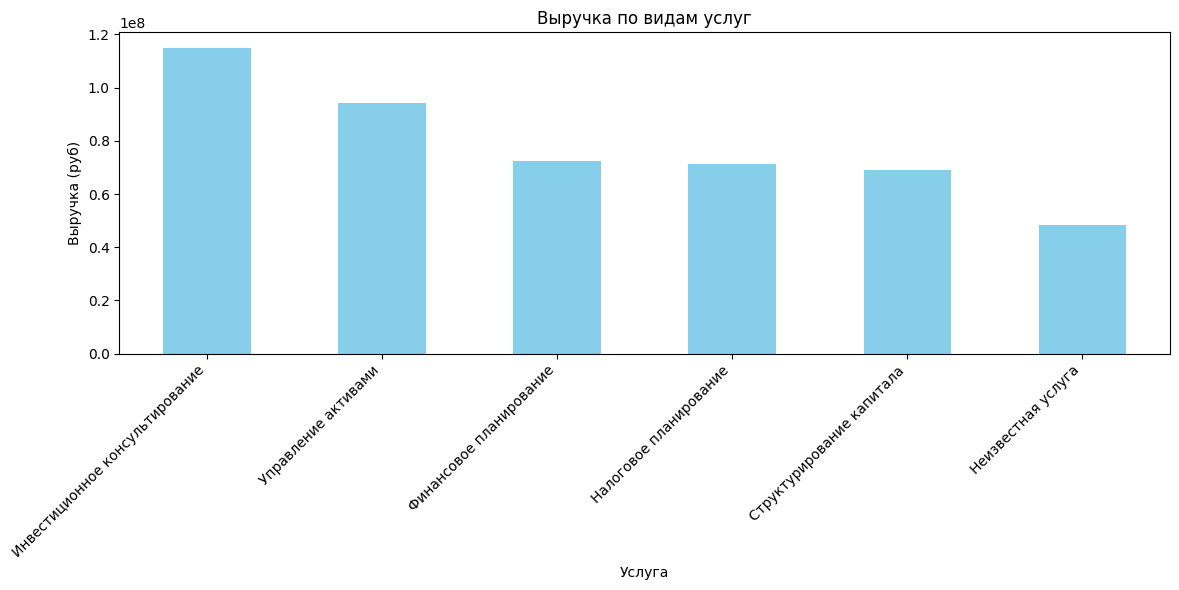

In [81]:
# Выручка по услугам (из транзакций, чтобы не потерять транзакции без клиентов)
service_revenue = transactions.groupby('service')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
service_revenue.plot(kind='bar', color='skyblue')
plt.title('Выручка по видам услуг')
plt.xlabel('Услуга')
plt.ylabel('Выручка (руб)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

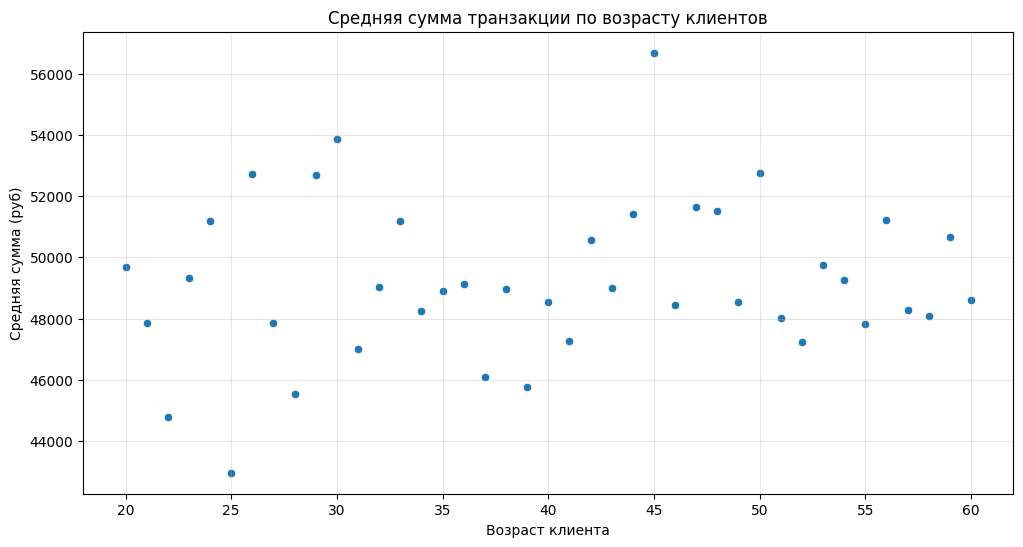

In [86]:
age_avg = merged.groupby('age')['amount'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=age_avg, x='age', y='amount')
plt.title('Средняя сумма транзакции по возрасту клиентов')
plt.xlabel('Возраст клиента')
plt.ylabel('Средняя сумма (руб)')
plt.grid(True, alpha=0.3)
plt.show()

Этап 5: прогнозирование

In [97]:
# группировка по месяцам

transactions['month'] = transactions['transaction_date'].dt.to_period('M')

monthly = transactions.groupby('month').agg(
    total_transactions=('transaction_id', 'count'),
    total_revenue=('amount', 'sum')
).reset_index()

print(monthly)

     month  total_transactions  total_revenue
0  2025-01                3379   1.711184e+08
1  2025-02                3082   1.480021e+08
2  2025-03                2104   1.052579e+08


In [102]:
x = np.array([1, 2, 3]).reshape(-1, 1)
y = monthly['total_revenue'].values

model = LinearRegression()
model.fit(x, y)

next_month_pred = model.predict([[4]])[0]
print(f"Прогноз выручки на следующий месяц: {next_month_pred:,.0f} руб.")

Прогноз выручки на следующий месяц: 75,598,941 руб.


Я предполагаю линейный тренд из-за малого кол-ва данных (всего 3 месяца)